In [1]:
# Imports

from IPython.display import HTML
import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import astropy.units as u
import stpsf
from winnie.modeling import (grater_nring_2hg_disk_model, obj_fn, lmfit_nrings_nptsrc_init, make_region_of_interest_mask)
from winnie.utils import (dist_to_pt, ang_size_to_px_size, ang_size_to_proj_sep, px_size_to_ang_size)
import lmfit

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

winnie.utils.setup_jupyter_display()

This tutorial provides an example of disk forward modeling for the MIRI Four Quadrant Phase Mask (4QPM / FQPM).

The data included are a SpaceKLIP reduction of the F1140C observations of HD 106906 (GTO 1277, PI: Pierre-Olivier Lagage) — using reference observations from GTO 1194 (PI: Chas Beichman). 

A detailed analysis of these data is reported in Rouan et al. (2025). For the sake of demonstration, we're adapting a simple scattered light model to crudely approximate what is truly a combination of scattered light and thermal emission. As such, I'd suggest taking the results with a grain of salt and will point to Rouan et al. (2025) for a much more meaningful physical investigation of this disk.

Pre-processing / calibration of FQPM for Winnie:

As of Aug 2026: for accurate forward modeling, you **MUST** skip the flat-fielding step in the Stage 2 pipeline.

For my purposes, I generally include the background images in the reference library as well. This makes the initial RDI reductions look much worse, but protects us against any BG over/under-subtraction that would otherwise impact our data without any comparable mechanism for our models. Final MCRDI reductions should effectively eliminate any background offset when processed this way.

Finally: I'll hazard that the 4QPM module for Winnie is a work in progress. Don't expect everything to work exactly the same as it does with Lyot data. There is a significant amount of nuance in creating transmission maps and sampling the FOV. Things work as demonstrated here, but other uses may well encounter major bugs (or NotImplemented errors).

In [60]:
# Prep the SpaceRDI object:
distance = 103. # Distance to your target in parsecs

base_dir = './hd106906_4qpm_example/'

input_dir = f'{base_dir}coadded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

concats = list(Database.obs.keys())

for concat in concats:
    dbtab = Database.obs[concat]
    dbtab['TYPE'] = np.where(dbtab['TYPE'] == 'SCI', 'SCI', 'REF') # Mark all BG files as refs so Winnie loads them into our reference library
    Database.obs[concat] = dbtab

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI', overwrite=True, verbose=True, pad_data='auto', r_opt=5*u.arcsec, save_coron_transmission=False)

wdb.load_concat(0)

JWST_MIRI_MIRIMAGE_F1140C_NONE_4QPM_1140_MASK1140
Science data:   1 exposures of shape (276,273)
Reference data: 12 exposures of shape (276,273)

RDI Settings:
Mode: RDI
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


In [61]:
# Running this will set up and run the PSF grid;
# BE AWARE: This will take a few hours to run!
# The MIRI 4QPM demands significantly more spatial
# samples to achieve suitable FM performance.

from synphot import SourceSpectrum, ReddeningLaw
from synphot.models import BlackBodyNorm1D

# Grid settings

# From my testing: this config works well for the typical target
# but feel free to fiddle with these settings
# (keeping in mind: run-time for forward modeling is roughly linear in the number of PSF samples)
# r0: adds samples for every (oversampled) pixel within r0 arcsec of the mask center
# rho0: (when nonzero) adds samples for every (oversampled) pixel within rho0 arcsec of an FQPM bound
# rho0_rmax is then the radial separation in arcsec out to which you want to include the rho0 samples; when rho0_rmax = None,
# it just uses the value of rmax instead.

grid_kwargs = dict(c_coron_rolls=wdb.c_coron_sci,
                   r0=0.5, 
                   rho0=0.0,
                   nr=8, 
                   rmax=3.5, 
                   nrho=18, 
                   rho0_rmax=None,
                   log_rscale=True, 
                   log_rhoscale=True,
                   normalize='exit_pupil',
                   nlambda=9)

wdb.convolver = None

Tdisk = 80.0 # Kelvin; approximating the disk spectrum as a blackbody of this temperature.
spec_synphot = SourceSpectrum(BlackBodyNorm1D, temperature=Tdisk)

# Run with prefetch_psf_grid = False so we can take a look at our grid before proceeding.
wdb.prepare_convolution(source_spectrum=spec_synphot, 
                        prefetch_psf_grid=True, 
                        fov_pixels=101, 
                        osamp=2,
                        grid_kwargs=grid_kwargs)

Setting up sim to match ./hd106906_4qpm_example/coadded/jw01277019001_04101_00001_mirimage_calints.fits

MAST OPD query around UTC: 2023-05-16T19:24:18.500
                        MJD: 60080.8085474537

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2023051601-NRCA3_FP1-1.fits
	Date (MJD):	 60080.3370
	Delta time:	 -0.4716 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2023051901-NRCA3_FP1-1.fits
	Date (MJD):	 60082.2208
	Delta time:	 1.4123 days
User requested choosing OPD time closest in time to 2023-05-16T19:24:18.500, which is O2023051601-NRCA3_FP1-1.fits, delta time -0.472 days
Importing and format-converting OPD from /Users/kdlawso1/jwst/data/stpsf-data/MAST_JWST_WSS_OPDs/O2023051601-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)
Sensing inst model using apername NRCA3_FP1
Using sensing field point SI WFE model from file wss_target_phase_fp1.fits

Configured simulation 

In [69]:
from copy import deepcopy

ring_params = [dict(r0=[70.0, 20.0, 100.0], # set initial value and use default ranges for min/max
                    pa=[104., 104.-10., 104.+10.], # or set initial, min, and max value
                    incl=[85.0, 80.0, 89.5],
                    ain=[2, 1., 20.], 
                    aout=[-6.,-20.,-1.],
                    h0=0.05)]

ptsrc_params = []

p = lmfit_nrings_nptsrc_init(ptsrc_params=ptsrc_params, 
                             ring_params=ring_params,
                             spf='twohg') # For longer wavelengths, spf='isotropic' (or swapping to a proper thermal disk modeling code) will likely be better
                                          # For 11 microns, we'll let the SPF vary to capture both the scattered light and thermal contributions.

for i in range(len(ring_params)):
    p[f'h0_{i+1}'].vary = False

# Adding an offset of the disk (~ eccentricity) improves the fit — though I can't promise this is physical.
p.add('xdo_1', value=0, min=-20, max=20)
p.add('ydo_1', value=0, min=-20, max=20)

p

name,value,initial value,min,max,vary
r0_1,70.0000000,70.0,20.0000000,100.000000,True
pa_1,104.000000,104.0,94.0000000,114.000000,True
incl_1,85.0000000,85.0,80.0000000,89.5000000,True
ain_1,2.00000000,2,1.00000000,20.0000000,True
aout_1,-6.00000000,-6.0,-20.0000000,-1.00000000,True
h0_1,0.05000000,0.05,1.0000e-03,0.10000000,False
beta_1,1.00000000,1.0,0.00000000,2.00000000,False
gamma_1,2.00000000,2.0,0.10000000,6.00000000,False
e_1,0.00000000,0.0,0.00000000,0.90000000,False
omega_1,0.00000000,0.0,-90.0000000,90.0000000,False


JWST_MIRI_MIRIMAGE_F1140C_NONE_4QPM_1140_MASK1140
Science data:   1 exposures of shape (276,273)
Reference data: 12 exposures of shape (276,273)

RDI Settings:
Mode: RDI
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


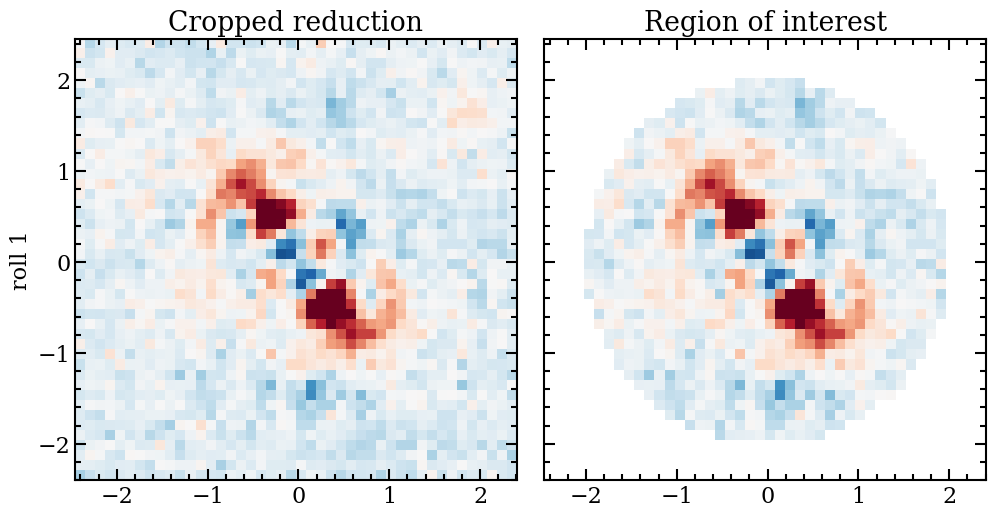

In [70]:
# Region of interest (ROI) settings:
roi_units = u.arcsec # Units for specifying the ROI; should work for u.pix or any angular units (u.arcsec, u.mas, u.deg, etc.)
roi_rmax = 2.0 # max radius (in units of roi_units) to include in the ROI
roi_rmin = 0.0 # min radius (in units of roi_units) to include in the ROI

###################
wdb.set_crop()
wdb.rdi_presets() # Set back to presets for a standard RDI reduction
wdb.r_opt = np.min([wdb.r_opt.value, roi_rmax])*u.arcsec
wdb.update_annular_zones()

# Cropped size to use during optimization. Should be large enough to include the entire disk (or at least the part you're interested in) plus some padding for convolution
npx_crop = int(2*(np.ceil(ang_size_to_px_size(roi_rmax, wdb.pxscale).value + 1*wdb._fwhm)))
crop_size = [npx_crop, npx_crop] # Cropped shape

wdb.set_crop(crop_size)
y1,y2,x1,x2 = wdb._crop_indices

# Rerun RDI on the cropped data:
rdi_reduc = wdb.run_rdi(save_products=False, derotate=False, correct_distortion=False)

# Generate the boolean region of interest mask
roi = make_region_of_interest_mask(rdi_reduc, wdb, rmin=roi_rmin, rmax=roi_rmax, units=roi_units)

# The largest separation (in au) at which to calculate the disk model. Here, we truncate the calculation at ~ the edge of the cropped FOV
rmax_accuracy = ang_size_to_proj_sep(px_size_to_ang_size(npx_crop/2., wdb.pxscale), distance).value # Convert to au

q_clip = None # see obj_fn docstring

err_weighting = np.where(rdi_reduc.err_rolls == 0, 1e12, rdi_reduc.err_rolls) # Err weighting, but there's a zero in the ERR array we need to fix.

kws = dict(err_weighting=err_weighting, q_clip=q_clip, rmax_accuracy=rmax_accuracy, disk_model_osamp=2)

fig,axes = quick_implot(np.array([rdi_reduc.rolls, np.where(roi, rdi_reduc.rolls, np.nan)]).transpose((1,0,2,3)), 
                             interpolation='None', cmap='RdBu_r', clim_perc=99, show=False,
                             show_ticks=True, extent=rdi_reduc.extent)

axes[0].set_title('Cropped reduction')
axes[1].set_title('Region of interest')
for i in range(len(rdi_reduc.rolls)):
    axes[::2][i].set_ylabel(f'roll {i+1}')
    
plt.show()

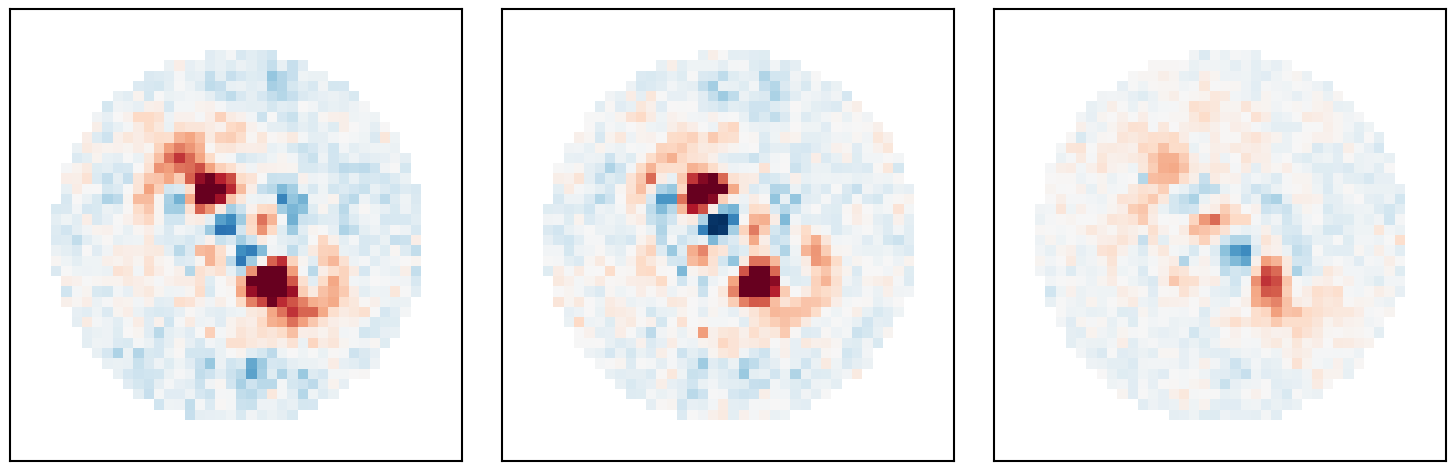

In [71]:
# Run a test model using the initialization and plot the result
out = obj_fn(p, rdi_reduc, wdb, roi, distance, count=False, halfNbSlices=25, return_soln=True, **kws)

modelcoeffs, modellabels, modelcubes, fmreducs, fmrdi_reduc, modelcube_composite, raw_disk_components, autoscale = out

pim = np.array([rdi_reduc.rolls, fmrdi_reduc.rolls, rdi_reduc.rolls-fmrdi_reduc.rolls]).transpose((1,0,2,3))

quick_implot(np.where(roi, pim, np.nan), clim_perc=99., cmap='RdBu_r', interpolation='None')

In [73]:
# Carry out the optimization procedure (should take ~300 iterations)
winnie.modeling.counter = 0

res = lmfit.minimize(obj_fn, p, method='powell',
                     args=[rdi_reduc, wdb, roi, distance], 
                     nan_policy='omit',
                     kws=dict(count=True, halfNbSlices=25, clear_each_call=False, **kws))

res

In [77]:
# Run derotated + distortion corrected results for the best-fit solution
wdb.set_crop()
wdb.rdi_presets()

rdi_reduc = wdb.run_rdi(save_products=True)
roi = make_region_of_interest_mask(rdi_reduc, wdb, rmin=roi_rmin, rmax=roi_rmax, units=roi_units)

err_weighting = np.where(rdi_reduc.err_rolls == 0, 1e12, rdi_reduc.err_rolls)

kws = dict(err_weighting=err_weighting, q_clip=q_clip, rmax_accuracy=rmax_accuracy, distorted_coords=True)

out = obj_fn(res.params, rdi_reduc, wdb, roi, distance, count=False, halfNbSlices=25, disk_model_osamp=2, return_soln=True, add_fm_eps=False, **kws)
modelcoeffs, modellabels, modelcubes, fmreducs, fmrdi_reduc, modelcube_composite, raw_disk_components, autoscale = out

wdb.set_circumstellar_model(modelcube_composite)
wdb.save_circumstellar_model()

fmrdi_reduc.save(overwrite=True)
model_reduc = wdb.make_model_reduc(match_reduc=rdi_reduc, save_products=True)

wdb.mcrdi_presets()
mcrdi_reduc = wdb.run_rdi(save_products=True)

JWST_MIRI_MIRIMAGE_F1140C_NONE_4QPM_1140_MASK1140
Science data:   1 exposures of shape (276,273)
Reference data: 12 exposures of shape (276,273)

RDI Settings:
Mode: RDI
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


[spaceKLIP.database:WARNING]   --> Could not find KL mode in header, assuming default value of 50


JWST_MIRI_MIRIMAGE_F1140C_NONE_4QPM_1140_MASK1140
Science data:   1 exposures of shape (276,273)
Reference data: 12 exposures of shape (276,273)

RDI Settings:
Mode: MCRDI
'hcube_css': <class 'numpy.ndarray'> of shape (1, 1, 276, 273)
Extension for output files: 'mcrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


[spaceKLIP.database:WARNING]   --> Could not find KL mode in header, assuming default value of 50


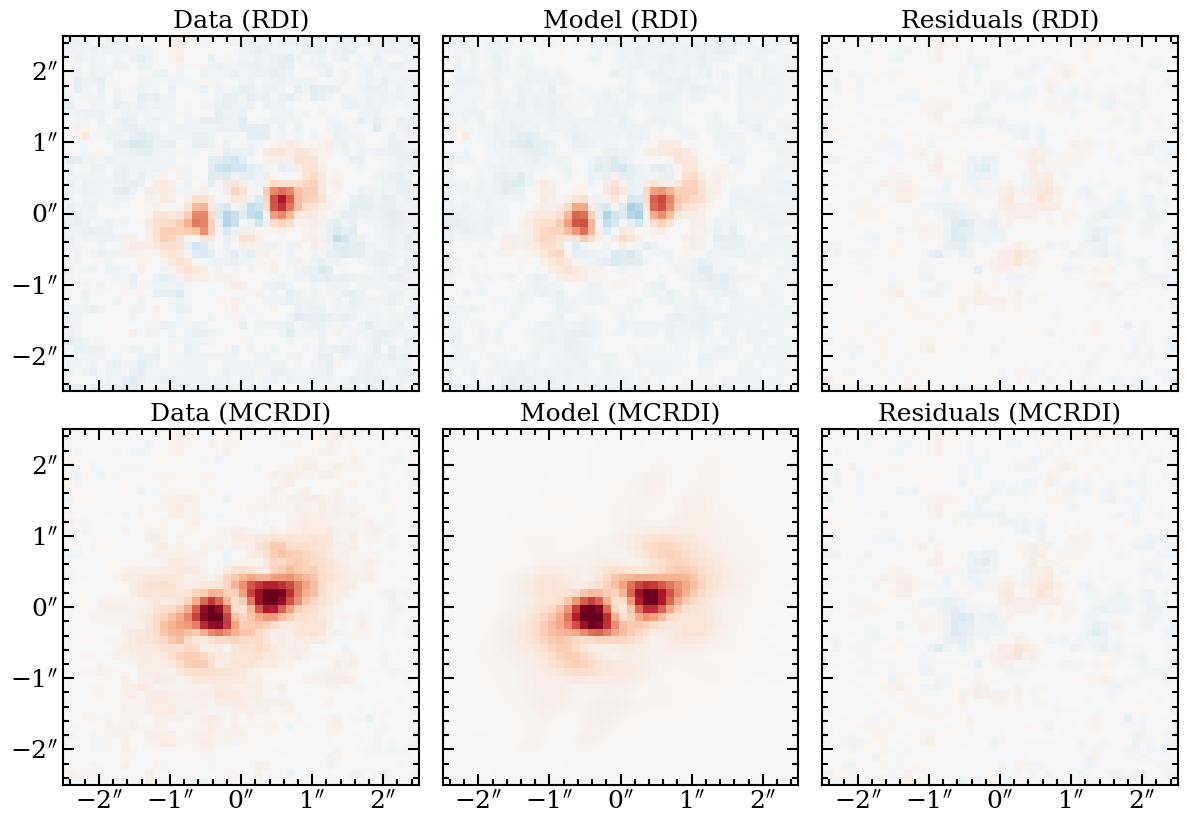

In [82]:
plot_args = dict(cmap='RdBu_r', clim_perc=99.995, show=False, panelsize=(4.,4.25),
                 extent=rdi_reduc.extent, lims=[-2.5,2.5], show_ticks=True)

# Plot all three reductions
fig,axes = quick_implot([[rdi_reduc.im, fmrdi_reduc.im, rdi_reduc.im-fmrdi_reduc.im],
                         [mcrdi_reduc.im, model_reduc.im, mcrdi_reduc.im-model_reduc.im]], 
                        **plot_args)

labels = ['Data (RDI)', 'Model (RDI)', 'Residuals (RDI)',
          'Data (MCRDI)', 'Model (MCRDI)', 'Residuals (MCRDI)']

for i,ax in enumerate(axes):
    ax.set_title(labels[i], fontsize=18)
    ax.tick_params(labelsize=18)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_locator(mpl.ticker.MaxNLocator(5, integer=True, min_n_ticks=5))
        axis.set_major_formatter("${x:0.0f}''$")

plt.savefig(f'{wdb.output_basedir}{wdb.output_subdir}/{wdb.concat}_reducs.pdf', bbox_inches='tight')

plt.show()

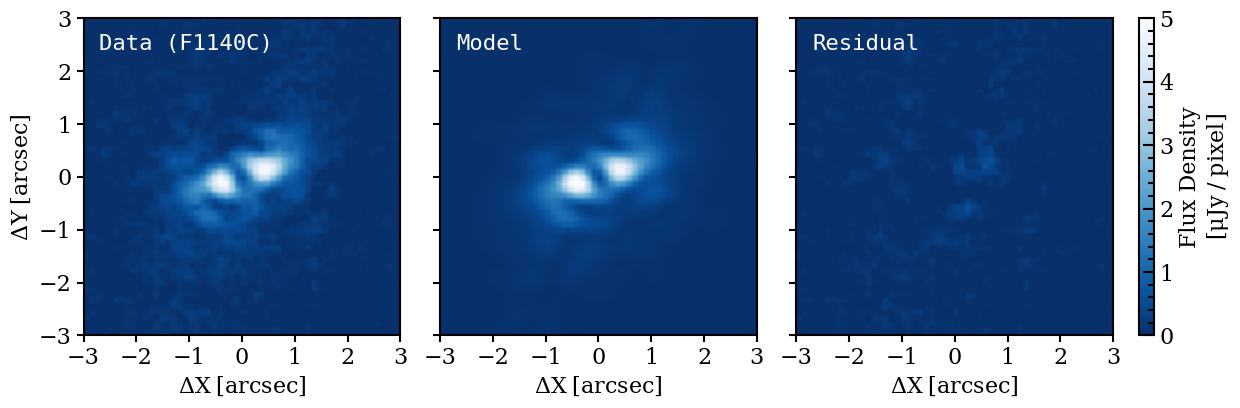

In [83]:
# Plot with styling to roughly match Fig 4 of Rouan et al. (2025)

pim = np.array([r.im for r in [mcrdi_reduc, model_reduc, mcrdi_reduc-model_reduc]])*(((1*u.MJy/u.sr).to(u.MJy/u.arcsec**2)*wdb.pxscale**2).to(u.microjansky/u.pix**2)).value

fig,axes,cbar = quick_implot(pim, clim_perc=99., extent=mcrdi_reduc.extent, lims=[-3,3], cmap='Blues_r', clim=[0,5], panelsize=(4.5,4), show=False, interpolation='hanning',
                             cbar=True, cbar_kwargs=dict(pad=0.02), cbar_label='Flux Density\n$[\mu Jy \\; / \\; pixel]$', show_ticks=True)

labels = [f'Data ({wdb.filt})', 'Model', 'Residual']

for i,ax in enumerate(axes):
    ax.minorticks_off()
    ax.set_xticks(np.arange(-3,4))
    ax.set_yticks(np.arange(-3,4))
    
    ax.tick_params(color='k', direction='out', right=False, top=False, length=5)
    
    ax.set_xlabel('$\Delta X \\; [arcsec]$')
    
    ax.text(0.05, 0.95, labels[i], family='monospace', ha='left', va='top', c='white', transform=ax.transAxes)

axes[0].set_ylabel('$\Delta Y \\; [arcsec]$')

plt.show()